## Part 1: All Models — Domain Score Heatmap

In [1]:
import json
import re
from pathlib import Path
from collections import defaultdict
import pandas as pd

BASE_DIR = Path("/scratch/pioneer/jobs/wxy320/save/cached_results/5x7/ids5_fields5_eq-1_alpha-1")

# results[model][domain][(hidden_slots, branch_budget)] = list of scores
results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for model_dir in sorted(BASE_DIR.iterdir()):
    if not model_dir.is_dir():
        continue
    model = model_dir.name
    for domain_dir in sorted(model_dir.iterdir()):
        if not domain_dir.is_dir():
            continue
        domain = domain_dir.name
        for instance_dir in sorted(domain_dir.iterdir()):
            if not instance_dir.is_dir():
                continue
            instance_id = instance_dir.name
            m = re.search(r'_h(\d+)_b(\d+)$', instance_id)
            if not m:
                continue
            hidden_slots = int(m.group(1))
            branch_budget = int(m.group(2))
            for jf in instance_dir.glob("*.json"):
                with open(jf) as f:
                    data = json.load(f)
                score = data.get("run_result", {}).get("score", None)
                results[model][domain][(hidden_slots, branch_budget)].append(score)

print("Models:", sorted(results.keys()))
print("Domains:", sorted(next(iter(results.values())).keys()))

Models: ['GLM-4.7-FP8', 'MiniMax-M2', 'MiniMax-M2.1', 'MiniMax-M2.5', 'MiroThinker-1.7-mini', 'Qwen3.5-0.8B', 'Qwen3.5-122B-A10B', 'Qwen3.5-27B', 'Qwen3.5-2B', 'Qwen3.5-35B-A3B', 'Qwen3.5-397B-A17B', 'Qwen3.5-4B', 'Qwen3.5-9B']
Domains: ['course', 'meal', 'pc_build', 'shopping', 'travel', 'workforce']


In [2]:
def _mean(vals):
    vs = [v for v in vals if v is not None]
    return sum(vs) / len(vs) if vs else None

rows = []
for model in sorted(results.keys()):
    for domain in sorted(results[model].keys()):
        for (h, b) in sorted(results[model][domain].keys()):
            entries = results[model][domain][(h, b)]
            valid = [s for s in entries if s is not None]
            rows.append({
                "model":         model,
                "domain":        domain,
                "hidden_slots":  h,
                "branch_budget": b,
                "score":         _mean(valid),
                "n":             len(valid),
            })

df = pd.DataFrame(rows)

# Summary table: model × domain mean score + overall
df_domain = (
    df.groupby(["model", "domain"])["score"]
    .mean()
    .unstack("domain")
)
df_domain["overall"] = df_domain.mean(axis=1)
df_sorted = df_domain.sort_values("overall", ascending=False)
df_sorted

domain,course,meal,pc_build,shopping,travel,workforce,overall
model,,,,,,,
Qwen3.5-397B-A17B,0.944444,0.814815,0.814815,0.833333,0.777778,0.907407,0.848765
Qwen3.5-122B-A10B,0.814815,0.740741,0.666667,0.777778,0.740741,0.759259,0.750000
Qwen3.5-27B,0.796296,0.796296,0.722222,0.740741,0.740741,0.685185,0.746914
Qwen3.5-35B-A3B,0.685185,0.740741,0.685185,0.740741,0.685185,0.611111,0.691358
MiniMax-M2.5,0.574074,0.555556,0.481481,0.685185,0.611111,0.611111,0.586420
MiniMax-M2.1,0.592593,0.537037,0.537037,0.574074,0.537037,0.648148,0.570988
GLM-4.7-FP8,0.444444,0.462963,0.481481,0.518519,0.407407,0.500000,0.469136
Qwen3.5-9B,0.518519,0.444444,0.425926,0.444444,0.462963,0.462963,0.459877
MiniMax-M2,0.388889,0.462963,0.425926,0.481481,0.444444,0.444444,0.441358


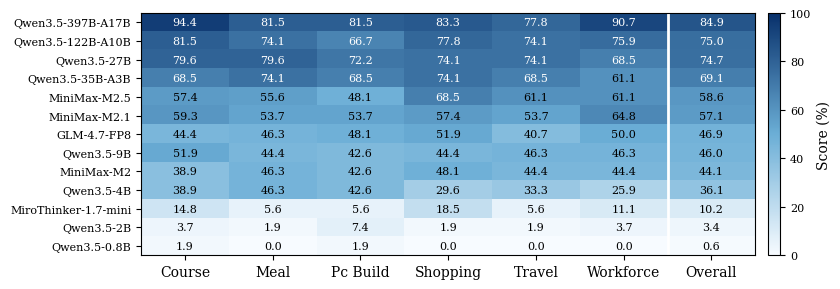

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 8,
})

domain_cols = [c for c in df_sorted.columns if c != "overall"]
col_order = domain_cols + ["overall"]
mat = df_sorted[col_order].values * 100

cmap = LinearSegmentedColormap.from_list(
    "paper_blues",
    ["#F7FBFF", "#6BAED6", "#08306B"]
)

fig, ax = plt.subplots(figsize=(8.5, 3))
im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=0, vmax=100)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        color = "white" if val > 65 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=8, color=color)

ax.axvline(len(domain_cols) - 0.5, color="white", linewidth=2)

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels([c.replace("_", " ").title() for c in col_order], rotation=0)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted.index)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Score (%)")

plt.tight_layout()
# plt.savefig("model_domain_heatmap_5x7.pdf", dpi=600, bbox_inches="tight")
plt.show()

## Part 2: Single Model — Hidden Slots × Decoy Budget Heatmap per Domain

In [7]:
import json
import re
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

MODEL_DIR = Path("/scratch/pioneer/jobs/wxy320/save/cached_results/5x7/ids5_fields5_eq-1_alpha-1/GLM-4.7-FP8")

# domain -> (hidden_slots, branch_budget) -> list of scores
domain_results = defaultdict(lambda: defaultdict(list))

for domain_dir in sorted(MODEL_DIR.iterdir()):
    if not domain_dir.is_dir():
        continue
    domain = domain_dir.name
    for instance_dir in sorted(domain_dir.iterdir()):
        if not instance_dir.is_dir():
            continue
        m = re.search(r'_h(\d+)_b(\d+)$', instance_dir.name)
        if not m:
            continue
        hidden_slots = int(m.group(1))
        branch_budget = int(m.group(2))
        for jf in instance_dir.glob("*.json"):
            with open(jf) as f:
                data = json.load(f)
            score = data.get("run_result", {}).get("score", None)
            domain_results[domain][(hidden_slots, branch_budget)].append(score)

print("Domains:", sorted(domain_results.keys()))

Domains: ['course', 'meal', 'pc_build', 'shopping', 'travel', 'workforce']


In [8]:
def _mean(vals):
    vs = [v for v in vals if v is not None]
    return sum(vs) / len(vs) if vs else None

rows = []
for domain in sorted(domain_results.keys()):
    for (h, b), entries in sorted(domain_results[domain].items()):
        rows.append({
            "domain":        domain,
            "hidden_slots":  h,
            "branch_budget": b,
            "score":         _mean(entries),
        })

df2 = pd.DataFrame(rows)

# pivot: hidden_slots × branch_budget for each domain
df_hb = (
    df2.groupby(["domain", "hidden_slots", "branch_budget"])["score"]
    .mean()
    .unstack("branch_budget")
    * 100
)
df_hb

branch_budget              0      2      4      8      10     15     19  \
domain    hidden_slots                                                    
course    1             100.0  100.0  100.0  100.0  100.0  100.0  100.0   
          5             100.0  100.0  100.0  100.0    0.0  100.0    0.0   
          7             100.0    0.0    0.0    0.0    0.0    0.0    0.0   
          11            100.0  100.0  100.0    0.0  100.0    0.0    0.0   
          15            100.0    0.0    0.0  100.0    0.0    0.0    0.0   
          21            100.0    0.0  100.0  100.0    0.0    0.0    0.0   
meal      1             100.0  100.0  100.0  100.0  100.0  100.0  100.0   
          5             100.0  100.0  100.0  100.0    0.0    0.0    0.0   
          7             100.0  100.0  100.0    0.0  100.0    0.0    0.0   
          11            100.0  100.0  100.0  100.0    0.0    0.0    0.0   
          15            100.0  100.0    0.0  100.0    0.0    0.0    0.0   
          21            100.0  100.0    0.0    0.0    0.0    0.0    0.0   
pc_build  1             100.0  100.0  100.0  100.0  100.0  100.0  100.0   
          5             100.0  100.0    0.0  100.0    0.0    0.0    0.0   
          7             100.0  100.0  100.0    0.0  100.0  100.0    0.0   
          11            100.0  100.0    0.0    0.0    0.0    0.0    0.0   
          15            100.0    0.0  100.0  100.0    0.0    0.0    0.0   
          21            100.0  100.0  100.0  100.0    0.0    0.0    0.0   
shopping  1             100.0    0.0  100.0  100.0  100.0  100.0    0.0   
          5             100.0  100.0  100.0  100.0  100.0    0.0    0.0   
          7             100.0  100.0  100.0  100.0    0.0    0.0    0.0   
          11            100.0  100.0  100.0  100.0    0.0  100.0    0.0   
          15            100.0  100.0  100.0    0.0    0.0  100.0    0.0   
          21            100.0    0.0  100.0    0.0    0.0    0.0    0.0   
travel    1             100.0  100.0  100.0  100.0  100.0  100.0  100.0   
          5             100.0    0.0  100.0  100.0    0.0    0.0    0.0   
          7             100.0  100.0  100.0    0.0    0.0    0.0    0.0   
          11            100.0  100.0  100.0    0.0    0.0    0.0    0.0   
          15            100.0    0.0    0.0  100.0    0.0    0.0    0.0   
          21            100.0  100.0    0.0    0.0    0.0    0.0    0.0   
workforce 1             100.0  100.0  100.0  100.0  100.0  100.0  100.0   
          5             100.0  100.0  100.0  100.0    0.0  100.0    0.0   
          7             100.0  100.0  100.0    0.0    0.0    0.0    0.0   
          11            100.0  100.0  100.0    0.0    0.0    0.0    0.0   
          15            100.0  100.0    0.0    0.0    0.0    0.0    0.0   
          21            100.0  100.0    0.0  100.0    0.0    0.0    0.0   

branch_budget              21     25  
domain    hidden_slots                
course    1             100.0  100.0  
          5               0.0    0.0  
          7               0.0    0.0  
          11              0.0    0.0  
          15              0.0    0.0  
          21              0.0    0.0  
meal      1               0.0  100.0  
          5               0.0    0.0  
          7               0.0    0.0  
          11              0.0    0.0  
          15              0.0    0.0  
          21              0.0    0.0  
pc_build  1             100.0  100.0  
          5               0.0    0.0  
          7               0.0    0.0  
          11              0.0    0.0  
          15              0.0    0.0  
          21              0.0    0.0  
shopping  1             100.0  100.0  
          5               0.0    0.0  
          7               0.0    0.0  
          11            100.0    0.0  
          15              0.0    0.0  
          21              0.0    0.0  
travel    1             100.0  100.0  
          5               0.0    0.0  
          7               0.0    0.0  
          11      

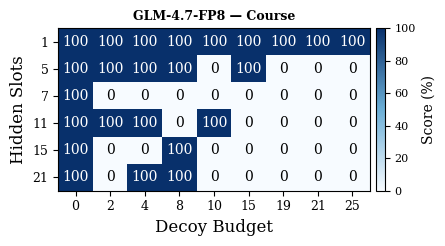

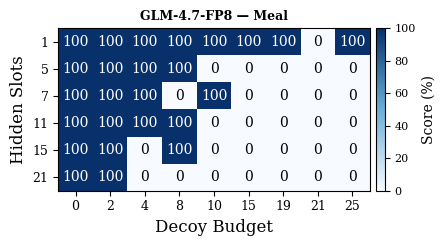

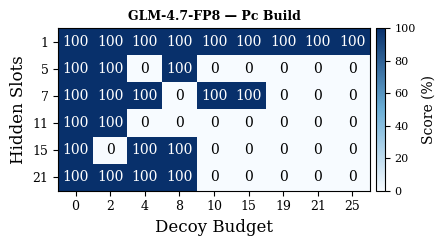

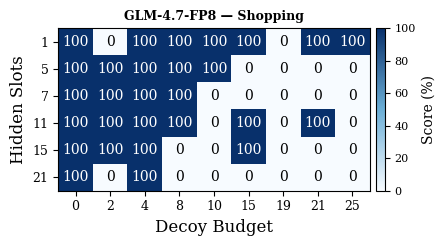

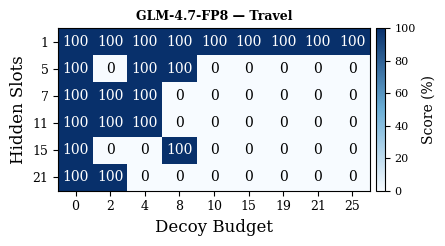

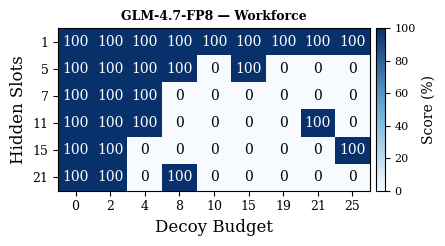

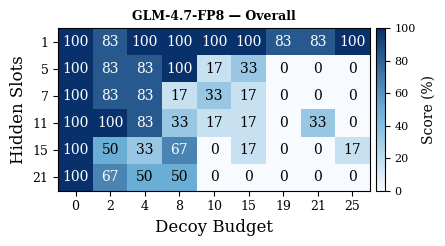

In [9]:
mpl.rcParams.update({"font.family": "serif", "font.size": 8})

cmap = LinearSegmentedColormap.from_list(
    "paper_blues",
    ["#F7FBFF", "#6BAED6", "#08306B"]
)

model_name = MODEL_DIR.name
domains = sorted(domain_results.keys())

for domain in domains:
    mat = df_hb.loc[domain]

    fig, ax = plt.subplots(figsize=(4.5, 2.5))
    im = ax.imshow(mat.values, aspect="auto", cmap=cmap, vmin=0, vmax=100)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            if np.isnan(val):
                continue
            txt_color = "white" if val > 65 else "black"
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                    fontsize=10, color=txt_color)

    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, fontsize=9)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=9)
    ax.set_xlabel("Decoy Budget", fontsize=12)
    ax.set_ylabel("Hidden Slots", fontsize=12)
    ax.set_title(f"{model_name} — {domain.replace('_', ' ').title()}", fontsize=9, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label("Score (%)")

    plt.tight_layout()
    fname = f"hb_heatmap_{model_name}_{domain}.pdf"
    # plt.savefig(fname, bbox_inches="tight")
    plt.show()

# ── Overall heatmap (mean across all domains) ────────────────
mat_overall = (
    df_hb.groupby(level="hidden_slots")
    .mean()
)

fig, ax = plt.subplots(figsize=(4.5, 2.5))
im = ax.imshow(mat_overall.values, aspect="auto", cmap=cmap, vmin=0, vmax=100)

for i in range(mat_overall.shape[0]):
    for j in range(mat_overall.shape[1]):
        val = mat_overall.values[i, j]
        if np.isnan(val):
            continue
        txt_color = "white" if val > 65 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=10, color=txt_color)

ax.set_xticks(range(len(mat_overall.columns)))
ax.set_xticklabels(mat_overall.columns, fontsize=9)
ax.set_yticks(range(len(mat_overall.index)))
ax.set_yticklabels(mat_overall.index, fontsize=9)
ax.set_xlabel("Decoy Budget", fontsize=12)
ax.set_ylabel("Hidden Slots", fontsize=12)
ax.set_title(f"{model_name} — Overall", fontsize=9, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Score (%)")

plt.tight_layout()
# plt.savefig(f"hb_heatmap_{model_name}_overall.pdf", bbox_inches="tight")
plt.show()
